Get only data up until 2025

In [110]:
import pandas as pd
import os
import sys

# Add the parent directory to the Python path to import from data.export
sys.path.append(os.path.abspath(".."))

df_2025_class = df_2025 = pd.read_csv("export/classification_data_2025.csv")

# duplicate study_id 4523 from merging 
df_2025_class = df_2025_class[df_2025_class['study_id'] != 4523]

len(df_2025_class['study_id'].unique()) 

5650

In [111]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go


def plot_task_stacked_bar(
    df: pd.DataFrame,
    x_task: str,
    group_task: str,
    exclude_labels: dict | None = None,
    merge_labels: dict | None = None,
    value_name: str = "n_studies",
    figsize=(12, 12),
):
    """
    Create a stacked bar plot where each x-category (e.g. substance) is stacked by groups (e.g. conditions).

    Parameters:
    - df: DataFrame with columns `study_id`, `task`, `label` (or additional group column).
    - x_task: task name to use for x-axis categories (rows where `task==x_task` and `label` becomes x).
    - group_task: task name to use for stacking (rows where `task==group_task` and `label` becomes group),
                  or an existing column name in `df` to use directly as group.
    - exclude_labels: optional dict mapping task -> list of labels to exclude before plotting.
    - value_name: name for the aggregated count column.
    - figsize: figure size.

    Returns the counts DataFrame used for plotting.
    """
    data = df.copy()

    # Apply exclusions (task -> list[label])
    if exclude_labels:
        for task_name, labels in exclude_labels.items():
            data = data[~((data["task"] == task_name) & (data["label"].isin(labels)))]

    if merge_labels:
        for task_name, mapping in merge_labels.items():
            for new_label, old_labels in mapping.items():
                mask = (data["task"] == task_name) & (data["label"].isin(old_labels))
                data.loc[mask, "label"] = new_label

    total_nr_studies_per_x = {}
    task_filtered = data[data['task'] == x_task]

    for label in task_filtered['label'].unique():
        # filter according to label
        df_filtered = task_filtered[task_filtered['label'] == label]
        total_nr_studies_per_x[label] = len(df_filtered['study_id'].unique())
    

    # Build left (x) dataframe from x_task
    left = data[data["task"] == x_task][["study_id", "label"]].rename(columns={"label": "x"})

    # Build right (group) dataframe either from task rows or from an existing column
    if group_task in data["task"].unique():
        right = data[data["task"] == group_task][["study_id", "label"]].rename(columns={"label": "group"})
    elif group_task in data.columns:
        right = data[["study_id", group_task]].rename(columns={group_task: "group"})
    else:
        raise ValueError(f"group_task '{group_task}' not found as a task or column in the dataframe")

    # Merge on study_id and count occurrences
    merged = pd.merge(left, right, on="study_id")
    counts = (
        merged.groupby(["x", "group"])["study_id"]
        .nunique()
        .reset_index(name=value_name)
    )

    # Pivot for stacked plotting
    pivot = counts.pivot_table(index="x", columns="group", values=value_name, fill_value=0)

    # order by total frequency
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # Color palette
    groups = pivot.columns.tolist()
    colors = plt.cm.get_cmap("tab20", len(groups))
    color_map = {g: colors(i) for i, g in enumerate(groups)}

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    result_rows = []

    for i, x_val in enumerate(pivot.index):
        row = pivot.loc[x_val]
        sorted_row = row.sort_values(ascending=False)

        bottom = 0
        total = total_nr_studies_per_x[x_val]

        for grp, val in sorted_row.items():
            if val == 0:
                continue

            pct = (val / total) * 100
            result_rows.append({
                "x": x_val,
                "group": grp,
                "count": int(val),
                "total": int(total),
                "percentage": pct,
            })

            ax.bar(
                x_val,
                val,
                bottom=bottom,
                color=color_map[grp],
                label=grp if i == 0 else "",
            )

            ax.text(
                x_val,
                bottom + val / 2,
                f"{int(val)}\n({pct:.1f}%)",
                ha="center",
                va="center",
                fontsize=7,
            )

            bottom += val

        ax.text(
            x_val,
            bottom + bottom * 0.02, 
            f"n={int(total)}",
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
        )

    # Legend cleanup
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title=group_task, bbox_to_anchor=(1.05, 1), loc="upper left")

    # Formatting
    ax.set_title(f"{group_task} across {x_task}")
    ax.set_xlabel(x_task)
    ax.set_ylabel("Count")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(result_rows)


def plot_task_stacked_bar_interactive(
    df: pd.DataFrame,
    x_task: str,
    group_task: str,
    exclude_labels: dict | None = None,
    merge_labels: dict | None = None,
    value_name: str = "n_studies",
):
    data = df.copy()

    if exclude_labels:
        for task_name, labels in exclude_labels.items():
            data = data[~((data["task"] == task_name) & (data["label"].isin(labels)))]

    if merge_labels:
        for task_name, mapping in merge_labels.items():
            for new_label, old_labels in mapping.items():
                mask = (data["task"] == task_name) & (data["label"].isin(old_labels))
                data.loc[mask, "label"] = new_label

    # Total studies per x
    task_filtered = data[data["task"] == x_task]
    total_nr_studies_per_x = (
        task_filtered.groupby("label")["study_id"]
        .nunique()
        .to_dict()
    )

    # Build left/right
    left = data[data["task"] == x_task][["study_id", "label"]].rename(columns={"label": "x"})

    if group_task in data["task"].unique():
        right = data[data["task"] == group_task][["study_id", "label"]].rename(columns={"label": "group"})
    elif group_task in data.columns:
        right = data[["study_id", group_task]].rename(columns={group_task: "group"})
    else:
        raise ValueError(f"group_task '{group_task}' not found")

    merged = pd.merge(left, right, on="study_id")

    counts = (
        merged.groupby(["x", "group"])["study_id"]
        .nunique()
        .reset_index(name=value_name)
    )

    # Pivot
    pivot = counts.pivot_table(index="x", columns="group", values=value_name, fill_value=0)

    # Sort x by total
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # Build result dataframe
    result_rows = []
    for x_val in pivot.index:
        total = total_nr_studies_per_x[x_val]
        for grp in pivot.columns:
            val = pivot.loc[x_val, grp]
            if val == 0:
                continue
            pct = (val / total) * 100
            result_rows.append({
                "x": x_val,
                "group": grp,
                "count": int(val),
                "total": int(total),
                "percentage": pct,
            })

    result_df = pd.DataFrame(result_rows)

    fig = go.Figure()

    unique_groups = list(pivot.columns)
    color_palette = px.colors.qualitative.Plotly
    color_map = {
        grp: color_palette[i % len(color_palette)]
        for i, grp in enumerate(unique_groups)
    }

    shown_groups = set()

    for x_val in pivot.index:
        row = pivot.loc[x_val]

        sorted_groups = row.sort_values(ascending=False)

        total = total_nr_studies_per_x[x_val]

        for grp, val in sorted_groups.items():
            if val == 0:
                continue

            pct = (val / total) * 100

            fig.add_trace(go.Bar(
                name=grp,
                x=[x_val],
                y=[val],
                marker=dict(color=color_map[grp]),
                customdata=[pct],
                hovertemplate=(
                    "<b>%{x}</b><br>"
                    f"{grp}<br>"
                    "Count: %{y}<br>"
                    "Percentage: %{customdata:.1f}%<extra></extra>"
                ),
                showlegend=grp not in shown_groups
            ))

            shown_groups.add(grp)

    fig.update_layout(
        barmode="stack",
        title=f"{group_task} across {x_task}",
        xaxis_title=x_task,
        yaxis_title="Count",
        xaxis_tickangle=-45,
        legend_title=group_task,
        height=700,
    )

    fig.show()

    return result_df


## Substances-Condition Analysis

### X: Substances, Y: Count of Studies, Segments: Conditions

In [112]:
counts = plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy", 'Ketamine']
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

In [136]:
counts = plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy", 'Ketamine']
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



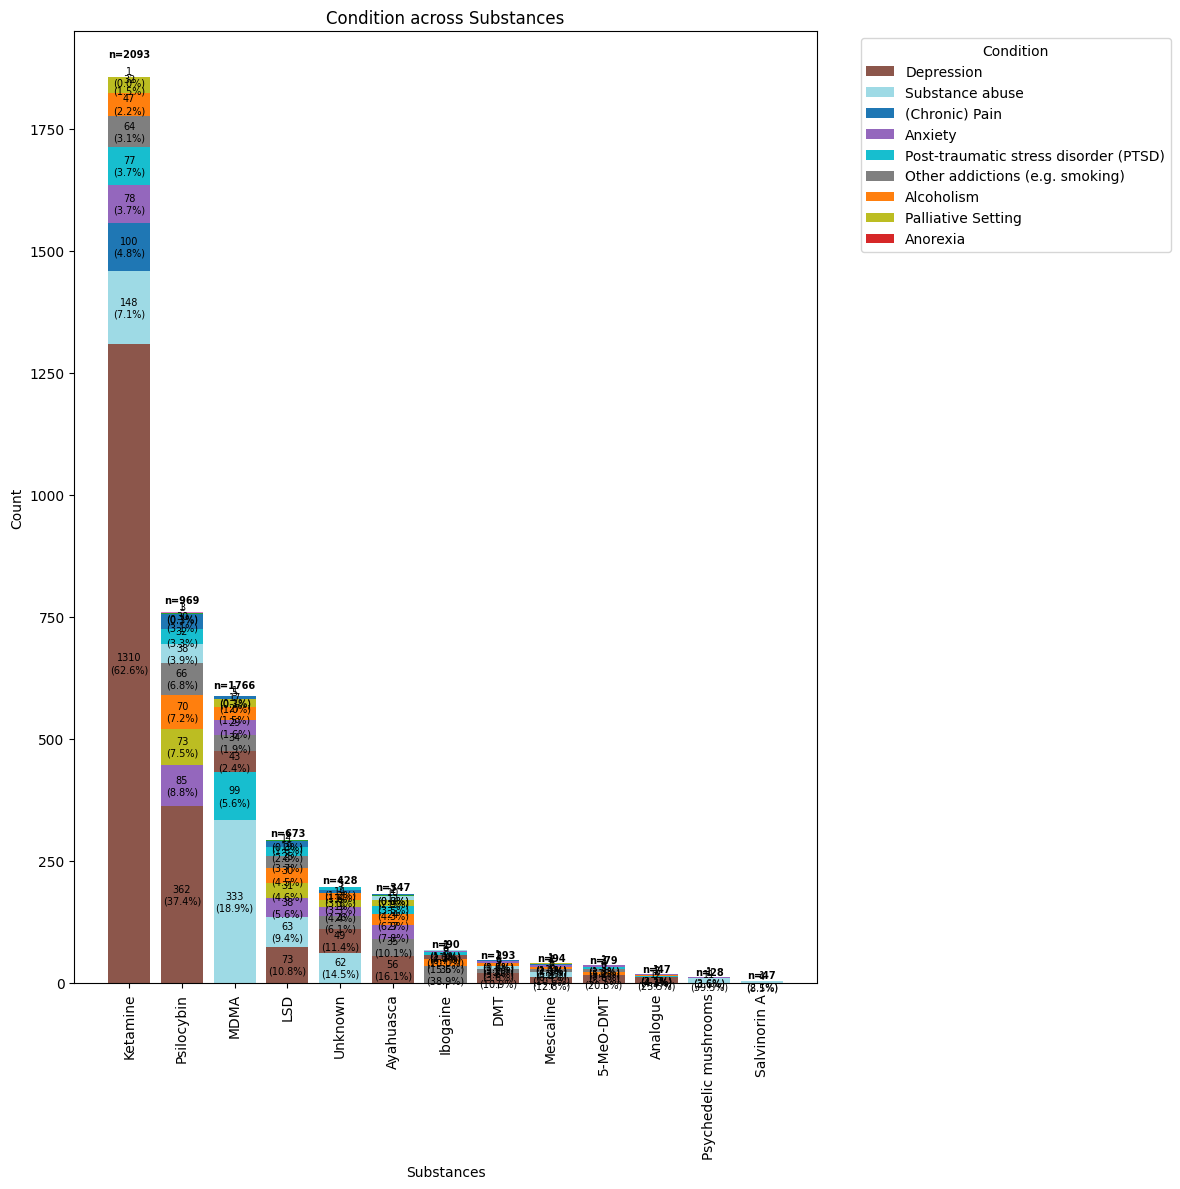

,x,group,count,total,percentage
0,Ketamine,Depression,1310,2093,62.589584
1,Ketamine,Substance abuse,148,2093,7.071190
2,Ketamine,(Chronic) Pain,100,2093,4.777831
3,Ketamine,Anxiety,78,2093,3.726708
4,Ketamine,Post-traumatic stress disorder (PTSD),77,2093,3.678930
...,...,...,...,...,...
87,Psychedelic mushrooms,Substance abuse,11,28,39.285714
88,Psychedelic mushrooms,Anxiety,1,28,3.571429
89,Psychedelic mushrooms,Depression,1,28,3.571429
90,Salvinorin A,Substance abuse,4,47,8.510638


In [114]:
plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy",  ]#"Ketamine", ]
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

In [115]:
plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use"],
        "Substances": ["Combination Therapy"]
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

,x,group,count,total,percentage
0,Ketamine,(Chronic) Pain,100,2093,4.777831
1,Ketamine,Alcoholism,47,2093,2.245581
2,Ketamine,Anorexia,1,2093,0.047778
3,Ketamine,Anxiety,78,2093,3.726708
4,Ketamine,Depression,1310,2093,62.589584
...,...,...,...,...,...
100,Salvinorin A,Substance abuse,4,47,8.510638
101,Psychedelic mushrooms,Anxiety,1,28,3.571429
102,Psychedelic mushrooms,Depression,1,28,3.571429
103,Psychedelic mushrooms,Healthy Participants,27,28,96.428571


### X: Condition, Y: Count of Studies, Segments: Substances

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



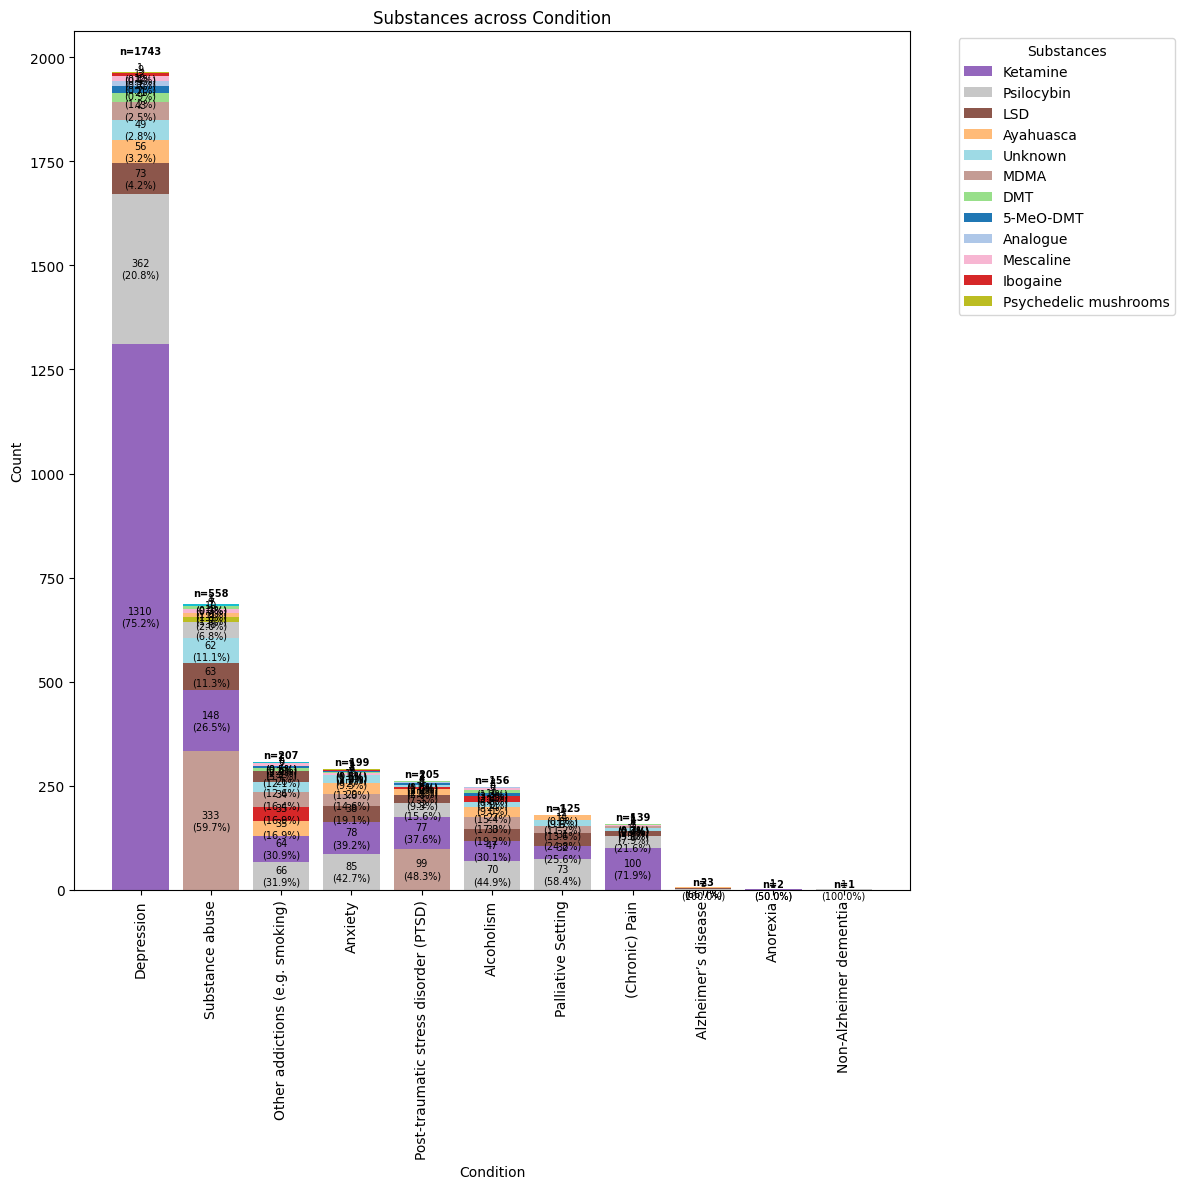

In [116]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Condition",
    group_task="Substances",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy"]
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

## Substances-Study Type/Control Analysis


### X: Substances, Y: Count of Studies, Segments: Study Type

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



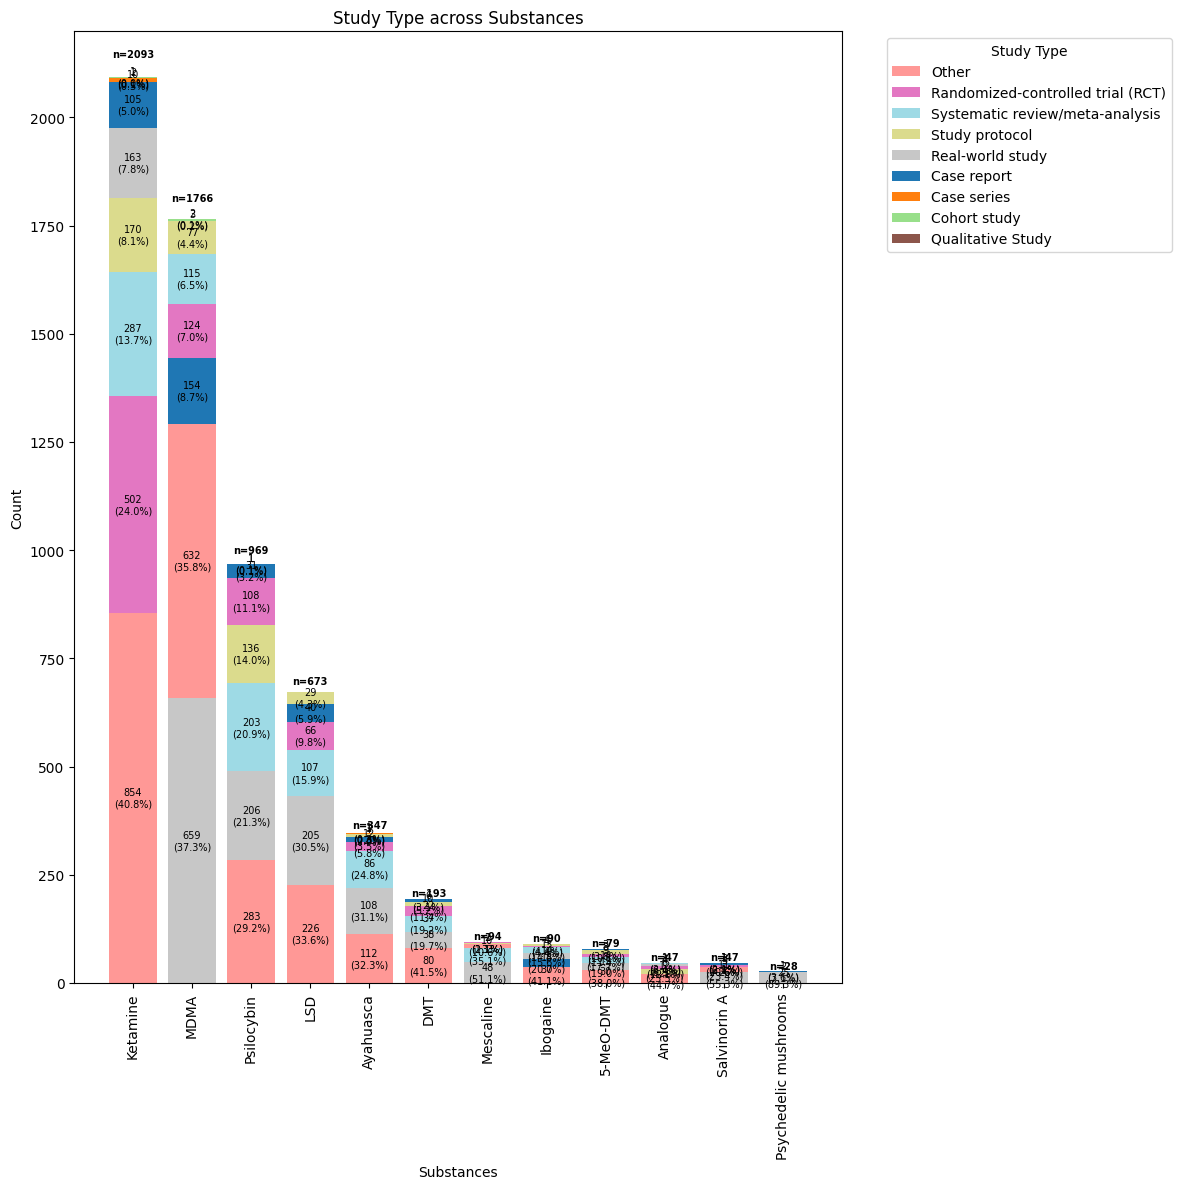

In [117]:
pct_sub_study_type = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Type",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"],
        # "Study Type": ["Other"]
    },
        merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)


In [118]:
plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Study Type",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"],
        # "Study Type": ["Other"]
    },
        merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)

,x,group,count,total,percentage
0,Ketamine,Case report,105,2093,5.016722
1,Ketamine,Case series,10,2093,0.477783
2,Ketamine,Cohort study,2,2093,0.095557
3,Ketamine,Other,854,2093,40.802676
4,Ketamine,Qualitative Study,1,2093,0.047778
...,...,...,...,...,...
72,Salvinorin A,Study protocol,1,47,2.127660
73,Salvinorin A,Systematic review/meta-analysis,1,47,2.127660
74,Psychedelic mushrooms,Case report,2,28,7.142857
75,Psychedelic mushrooms,Real-world study,25,28,89.285714


What substance has the highest number/proportion of Randomized Controlled Trials (RCTs)?

In [119]:
rct_df = pct_sub_study_type[pct_sub_study_type["group"] == "Randomized-controlled trial (RCT)"]

rct_sorted = rct_df.sort_values(by="percentage", ascending=False)
print(rct_sorted)

               x                              group  count  total  percentage
1       Ketamine  Randomized-controlled trial (RCT)    502   2093   23.984711
64      Analogue  Randomized-controlled trial (RCT)      6     47   12.765957
42           DMT  Randomized-controlled trial (RCT)     22    193   11.398964
59     5-MeO-DMT  Randomized-controlled trial (RCT)      9     79   11.392405
21    Psilocybin  Randomized-controlled trial (RCT)    108    969   11.145511
70  Salvinorin A  Randomized-controlled trial (RCT)      5     47   10.638298
28           LSD  Randomized-controlled trial (RCT)     66    673    9.806835
12          MDMA  Randomized-controlled trial (RCT)    124   1766    7.021518
34     Ayahuasca  Randomized-controlled trial (RCT)     20    347    5.763689
54      Ibogaine  Randomized-controlled trial (RCT)      4     90    4.444444
49     Mescaline  Randomized-controlled trial (RCT)      1     94    1.063830


In [120]:
rct_sorted = rct_df.sort_values(by="count", ascending=False)
print(rct_sorted)


               x                              group  count  total  percentage
1       Ketamine  Randomized-controlled trial (RCT)    502   2093   23.984711
12          MDMA  Randomized-controlled trial (RCT)    124   1766    7.021518
21    Psilocybin  Randomized-controlled trial (RCT)    108    969   11.145511
28           LSD  Randomized-controlled trial (RCT)     66    673    9.806835
42           DMT  Randomized-controlled trial (RCT)     22    193   11.398964
34     Ayahuasca  Randomized-controlled trial (RCT)     20    347    5.763689
59     5-MeO-DMT  Randomized-controlled trial (RCT)      9     79   11.392405
64      Analogue  Randomized-controlled trial (RCT)      6     47   12.765957
70  Salvinorin A  Randomized-controlled trial (RCT)      5     47   10.638298
54      Ibogaine  Randomized-controlled trial (RCT)      4     90    4.444444
49     Mescaline  Randomized-controlled trial (RCT)      1     94    1.063830


Which substances have the highest number/proportion of Real-World Studies?

In [121]:
rct_df = pct_sub_study_type[pct_sub_study_type["group"] == "Real-world study"]

rct_sorted = rct_df.sort_values(by="percentage", ascending=False)
print(rct_sorted)

                        x             group  count  total  percentage
74  Psychedelic mushrooms  Real-world study     25     28   89.285714
68           Salvinorin A  Real-world study     26     47   55.319149
45              Mescaline  Real-world study     48     94   51.063830
9                    MDMA  Real-world study    659   1766   37.315968
32              Ayahuasca  Real-world study    108    347   31.123919
26                    LSD  Real-world study    205    673   30.460624
18             Psilocybin  Real-world study    206    969   21.259030
40                    DMT  Real-world study     38    193   19.689119
57              5-MeO-DMT  Real-world study     15     79   18.987342
52               Ibogaine  Real-world study     14     90   15.555556
65               Analogue  Real-world study      4     47    8.510638
4                Ketamine  Real-world study    163   2093    7.787864


In [122]:
rct_sorted = rct_df.sort_values(by="count", ascending=False)
print(rct_sorted)

                        x             group  count  total  percentage
9                    MDMA  Real-world study    659   1766   37.315968
18             Psilocybin  Real-world study    206    969   21.259030
26                    LSD  Real-world study    205    673   30.460624
4                Ketamine  Real-world study    163   2093    7.787864
32              Ayahuasca  Real-world study    108    347   31.123919
45              Mescaline  Real-world study     48     94   51.063830
40                    DMT  Real-world study     38    193   19.689119
68           Salvinorin A  Real-world study     26     47   55.319149
74  Psychedelic mushrooms  Real-world study     25     28   89.285714
57              5-MeO-DMT  Real-world study     15     79   18.987342
52               Ibogaine  Real-world study     14     90   15.555556
65               Analogue  Real-world study      4     47    8.510638


Which substances have the highest number/proportion of case reports for each condition?

In [123]:
rct_df = pct_sub_study_type[pct_sub_study_type["group"] == "Case report"]

rct_sorted = rct_df.sort_values(by="percentage", ascending=False)
print(rct_sorted)

                        x        group  count  total  percentage
51               Ibogaine  Case report     18     90   20.000000
11                   MDMA  Case report    154   1766    8.720272
75  Psychedelic mushrooms  Case report      2     28    7.142857
71           Salvinorin A  Case report      3     47    6.382979
29                    LSD  Case report     40    673    5.943536
5                Ketamine  Case report    105   2093    5.016722
61              5-MeO-DMT  Case report      3     79    3.797468
35              Ayahuasca  Case report     12    347    3.458213
22             Psilocybin  Case report     31    969    3.199174
44                    DMT  Case report      6    193    3.108808
67               Analogue  Case report      1     47    2.127660


In [124]:
review_df = pct_sub_study_type[pct_sub_study_type["group"] == "Systematic review/meta-analysis"]

review_sorted = review_df.sort_values(by="percentage", ascending=False)
print(review_sorted)

               x                            group  count  total  percentage
46     Mescaline  Systematic review/meta-analysis     33     94   35.106383
33     Ayahuasca  Systematic review/meta-analysis     86    347   24.783862
19    Psilocybin  Systematic review/meta-analysis    203    969   20.949432
41           DMT  Systematic review/meta-analysis     37    193   19.170984
58     5-MeO-DMT  Systematic review/meta-analysis     14     79   17.721519
27           LSD  Systematic review/meta-analysis    107    673   15.898960
53      Ibogaine  Systematic review/meta-analysis     13     90   14.444444
2       Ketamine  Systematic review/meta-analysis    287   2093   13.712375
13          MDMA  Systematic review/meta-analysis    115   1766    6.511891
66      Analogue  Systematic review/meta-analysis      3     47    6.382979
73  Salvinorin A  Systematic review/meta-analysis      1     47    2.127660


### X: Study Type, Y: Count of Studies, Segments: Substances

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



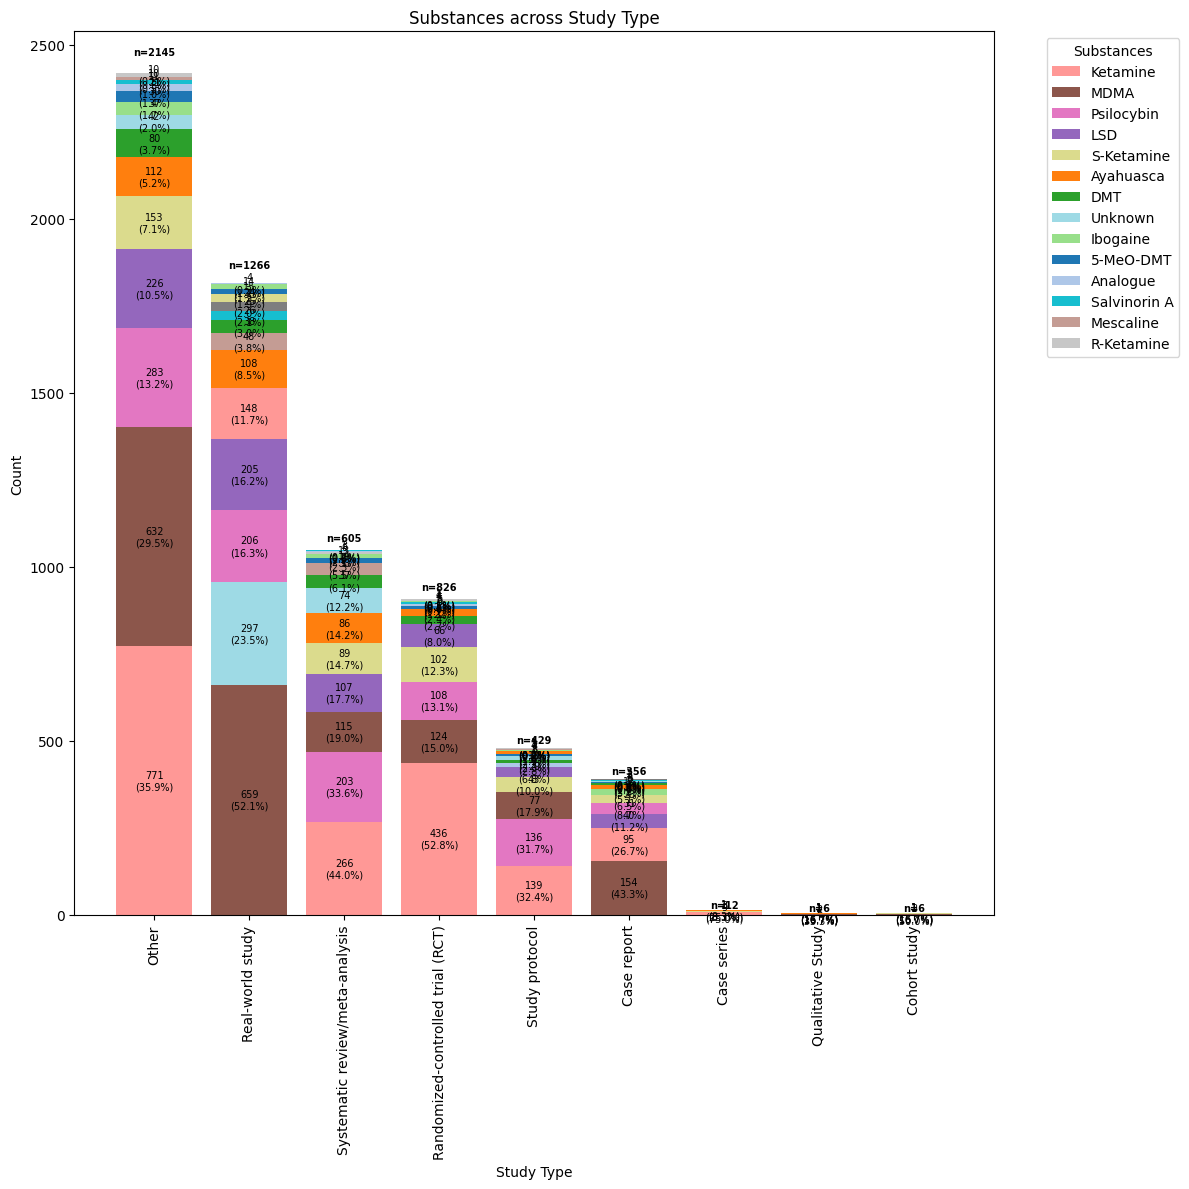

In [125]:
pct_study_type = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Type",
    group_task="Substances",
    exclude_labels={   
        "Substances": ["Combination Therapy"]
    }
)


### X: Substance, Y: Counts, Segments: Control

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



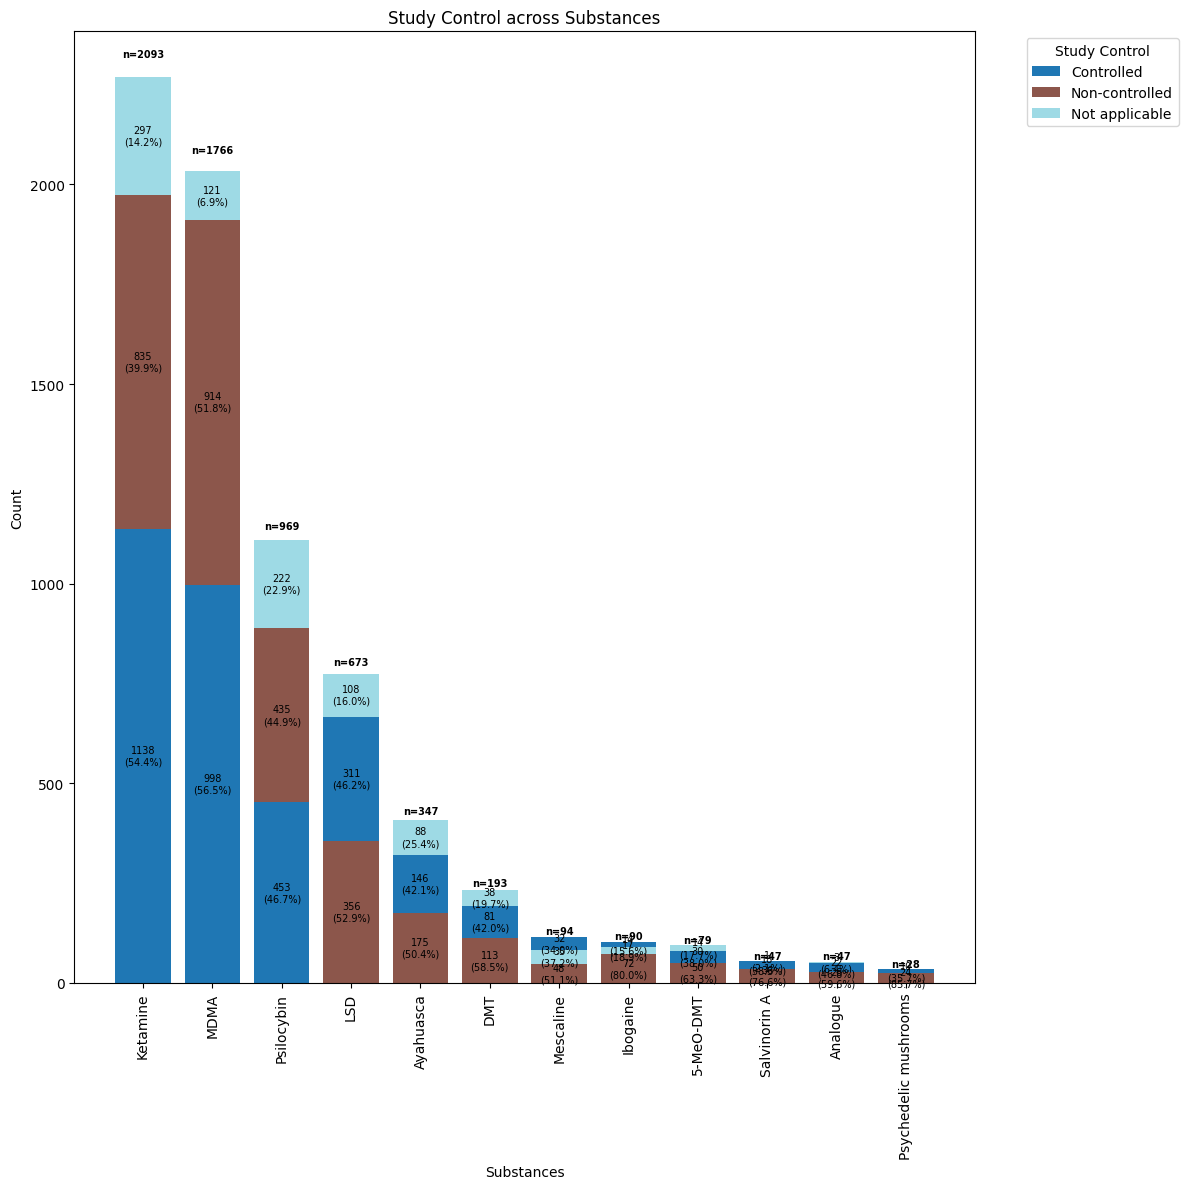

In [126]:
pct_control = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Control",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"]
    },
    merge_labels={
        'Study Control': {
            'Controlled': ['Placebo', 'Other control', 'Active control']
        },
        'Substances': {
            'Ketamine': ['Ketamine', 'R-Ketamine', 'S-Ketamine']
        }
    }
)

In [127]:
control = pct_control[pct_control["group"] == "Controlled"]
rct_sorted = control.sort_values(by="percentage", ascending=False)
print(rct_sorted)

                        x       group  count  total  percentage
3                    MDMA  Controlled    998   1766   56.511891
0                Ketamine  Controlled   1138   2093   54.371715
31               Analogue  Controlled     22     47   46.808511
6              Psilocybin  Controlled    453    969   46.749226
10                    LSD  Controlled    311    673   46.210996
13              Ayahuasca  Controlled    146    347   42.074928
16                    DMT  Controlled     81    193   41.968912
28           Salvinorin A  Controlled     18     47   38.297872
25              5-MeO-DMT  Controlled     30     79   37.974684
34  Psychedelic mushrooms  Controlled     10     28   35.714286
20              Mescaline  Controlled     32     94   34.042553
23               Ibogaine  Controlled     14     90   15.555556


In [128]:
uncontrol = pct_control[pct_control["group"] == "Non-controlled"]
controlled = uncontrol.sort_values(by="percentage", ascending=False)
print(controlled)

                        x           group  count  total  percentage
33  Psychedelic mushrooms  Non-controlled     24     28   85.714286
21               Ibogaine  Non-controlled     72     90   80.000000
27           Salvinorin A  Non-controlled     36     47   76.595745
24              5-MeO-DMT  Non-controlled     50     79   63.291139
30               Analogue  Non-controlled     28     47   59.574468
15                    DMT  Non-controlled    113    193   58.549223
9                     LSD  Non-controlled    356    673   52.897474
4                    MDMA  Non-controlled    914   1766   51.755379
18              Mescaline  Non-controlled     48     94   51.063830
12              Ayahuasca  Non-controlled    175    347   50.432277
7              Psilocybin  Non-controlled    435    969   44.891641
1                Ketamine  Non-controlled    835   2093   39.894888


### X: Contorl, Y: Counts, Segements: Substances 

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



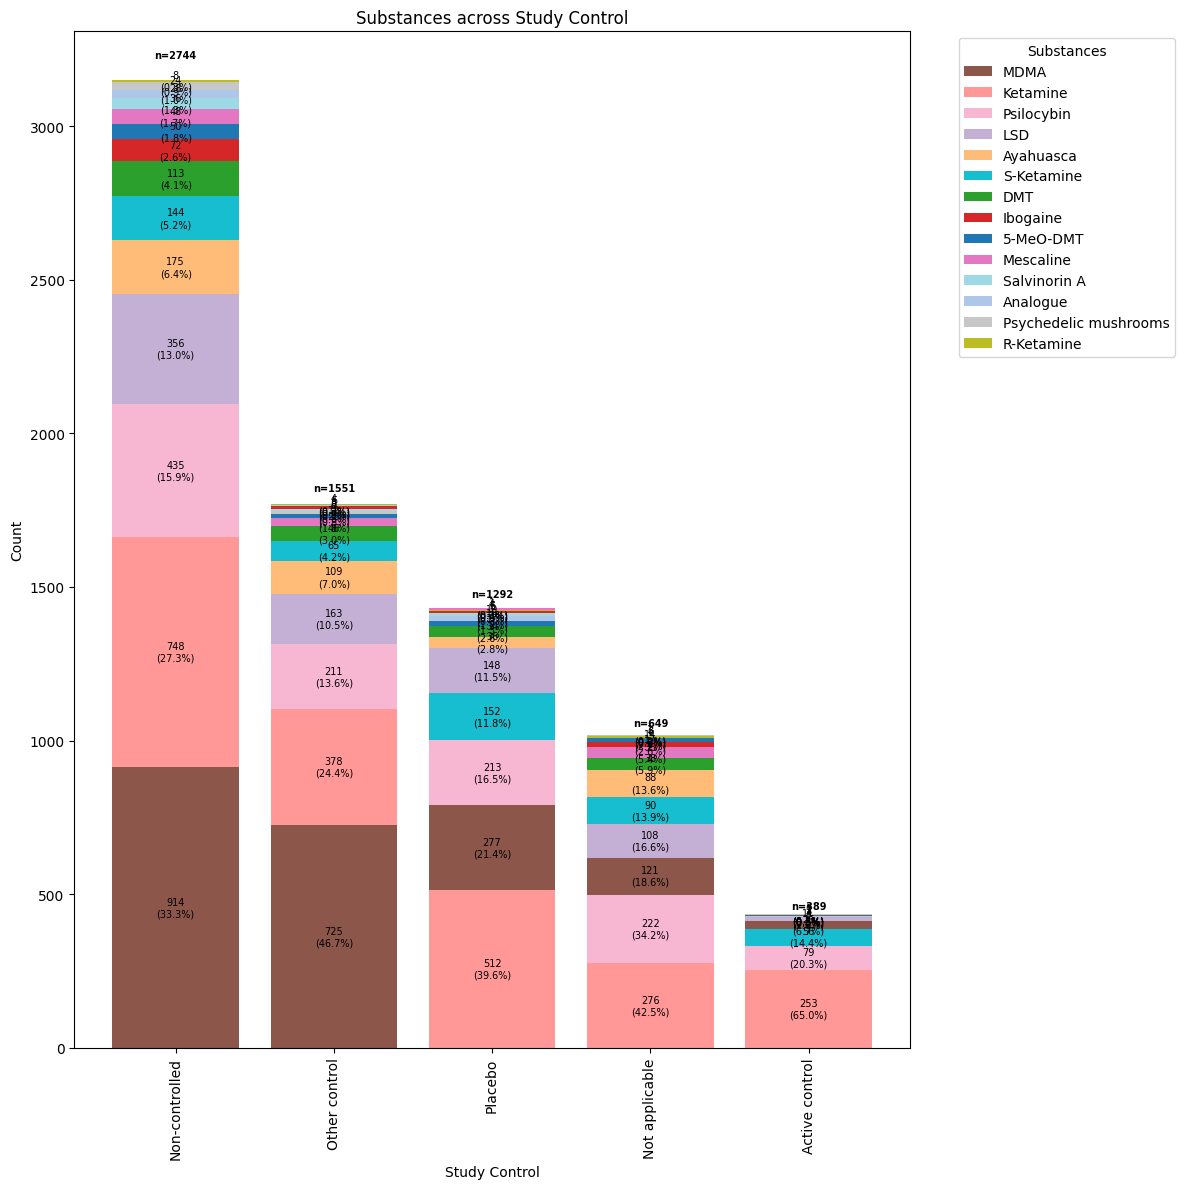

In [129]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Control",
    group_task="Substances",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"]
    }
)

## Substances-Study Purpose Analysis

### X: substances, Y: counts, Segments: study purpose

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



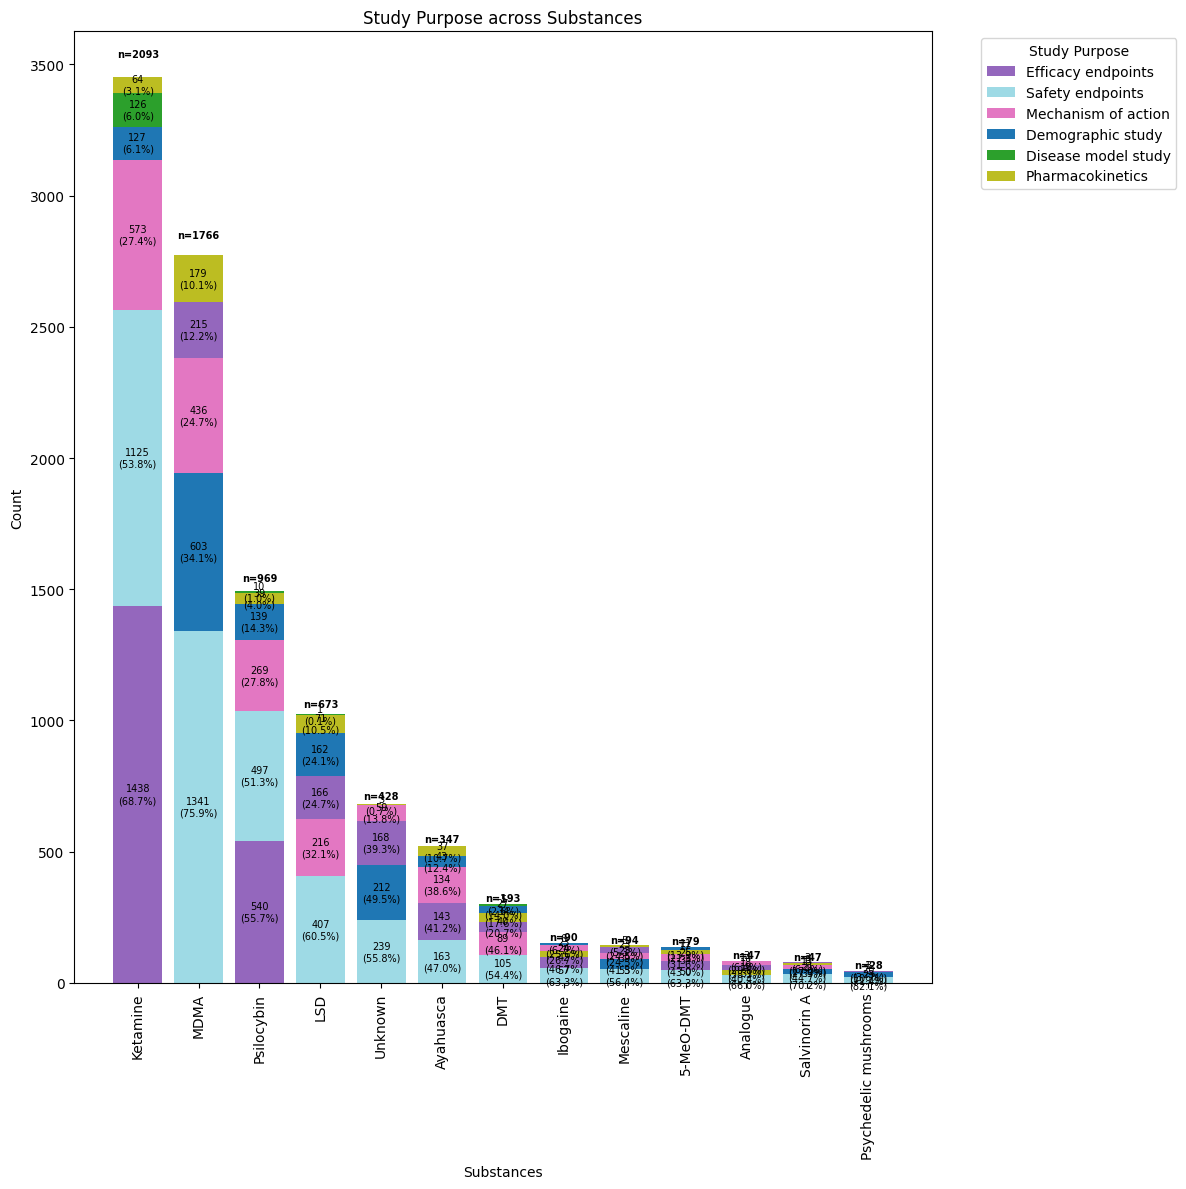

In [130]:
study_purpose = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Purpose",
    exclude_labels={
        "Substances": ['Other', 'Unkown', 'Combination Therapy']
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)


In [131]:
df_study_purpose = plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Study Purpose",
    exclude_labels={
        "Substances": ['Other', 'Unkown', 'Combination Therapy']
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)


In [132]:
sp_df = study_purpose[study_purpose["group"] == "Mechanism of action"]

sp_sorted = sp_df.sort_values(by="percentage", ascending=False)
print(sp_sorted)

                        x                group  count  total  percentage
34                    DMT  Mechanism of action     89    193   46.113990
30              Ayahuasca  Mechanism of action    134    347   38.616715
18                    LSD  Mechanism of action    216    673   32.095097
51              5-MeO-DMT  Mechanism of action     25     79   31.645570
57               Analogue  Mechanism of action     14     47   29.787234
13             Psilocybin  Mechanism of action    269    969   27.760578
61           Salvinorin A  Mechanism of action     13     47   27.659574
2                Ketamine  Mechanism of action    573   2093   27.376971
42               Ibogaine  Mechanism of action     23     90   25.555556
8                    MDMA  Mechanism of action    436   1766   24.688562
46              Mescaline  Mechanism of action     23     94   24.468085
26                Unknown  Mechanism of action     59    428   13.785047
67  Psychedelic mushrooms  Mechanism of action     

In [133]:
sp_df = study_purpose[study_purpose["group"] == "Demographic study"]

sp_sorted = sp_df.sort_values(by="percentage", ascending=False)
print(sp_sorted)

                        x              group  count  total  percentage
65  Psychedelic mushrooms  Demographic study     20     28   71.428571
24                Unknown  Demographic study    212    428   49.532710
60           Salvinorin A  Demographic study     21     47   44.680851
45              Mescaline  Demographic study     39     94   41.489362
7                    MDMA  Demographic study    603   1766   34.144960
20                    LSD  Demographic study    162    673   24.071322
14             Psilocybin  Demographic study    139    969   14.344685
37                    DMT  Demographic study     27    193   13.989637
53              5-MeO-DMT  Demographic study     11     79   13.924051
31              Ayahuasca  Demographic study     43    347   12.391931
43               Ibogaine  Demographic study      6     90    6.666667
58               Analogue  Demographic study      3     47    6.382979
3                Ketamine  Demographic study    127   2093    6.067845


In [134]:
sp_sorted = sp_df.sort_values(by="count", ascending=False)
print(sp_sorted)


                        x              group  count  total  percentage
7                    MDMA  Demographic study    603   1766   34.144960
24                Unknown  Demographic study    212    428   49.532710
20                    LSD  Demographic study    162    673   24.071322
14             Psilocybin  Demographic study    139    969   14.344685
3                Ketamine  Demographic study    127   2093    6.067845
31              Ayahuasca  Demographic study     43    347   12.391931
45              Mescaline  Demographic study     39     94   41.489362
37                    DMT  Demographic study     27    193   13.989637
60           Salvinorin A  Demographic study     21     47   44.680851
65  Psychedelic mushrooms  Demographic study     20     28   71.428571
53              5-MeO-DMT  Demographic study     11     79   13.924051
43               Ibogaine  Demographic study      6     90    6.666667
58               Analogue  Demographic study      3     47    6.382979


### X: Study Purpose, Y: Counts, Segments: Substances

/tmp/ipykernel_322899/1040414923.py:80: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



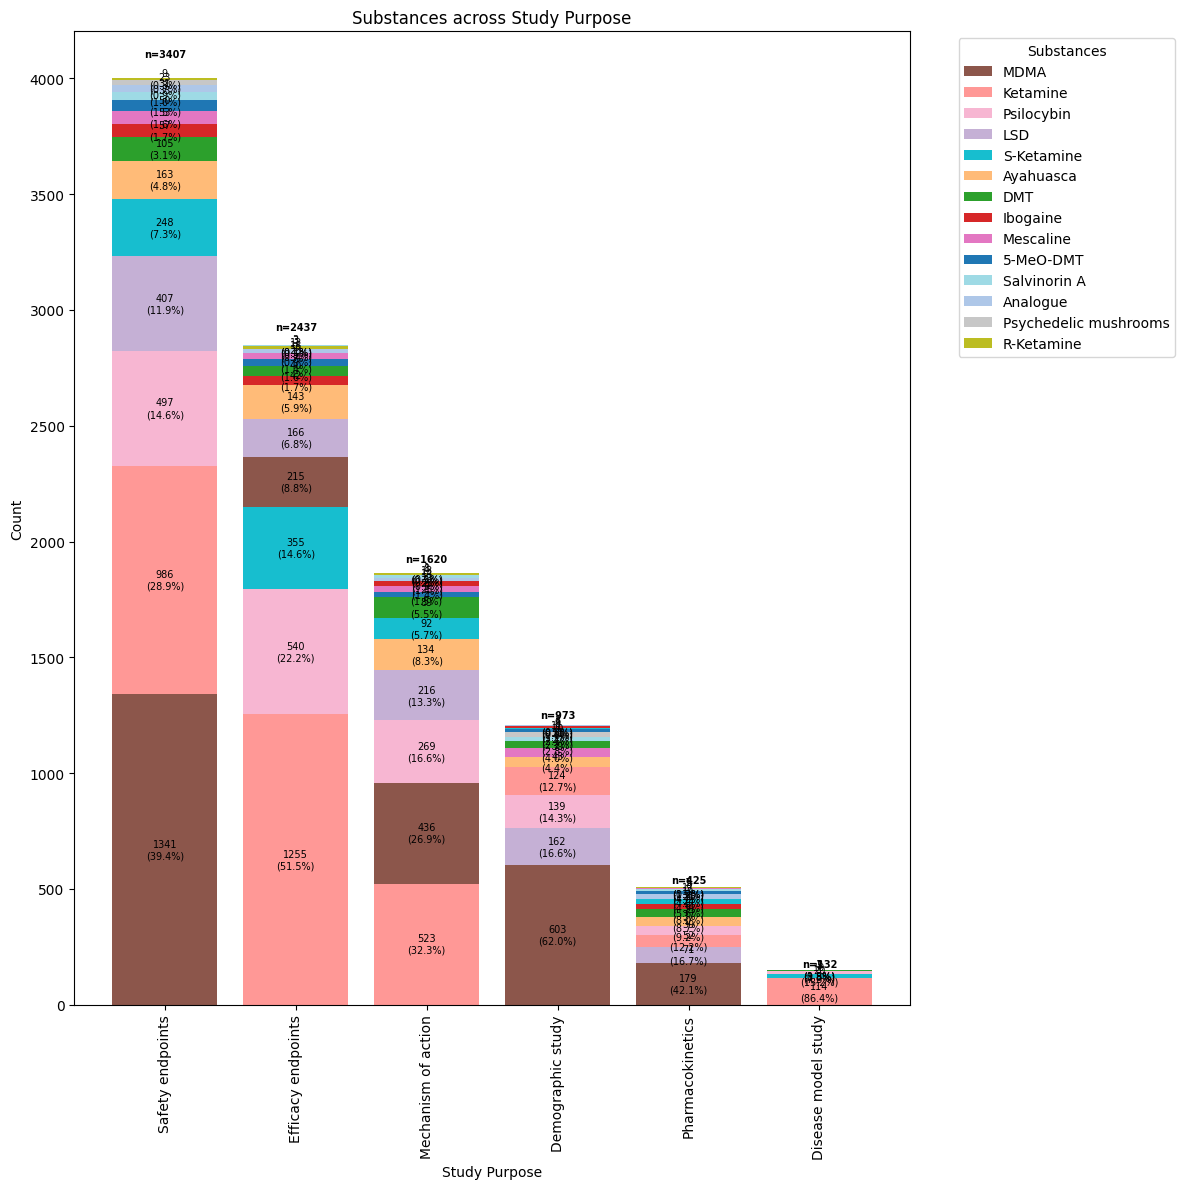

In [135]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Purpose",
    group_task="Substances",
    exclude_labels={
        "Substances": ['Other', 'Unknown', 'Combination Therapy']
    }
)